In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

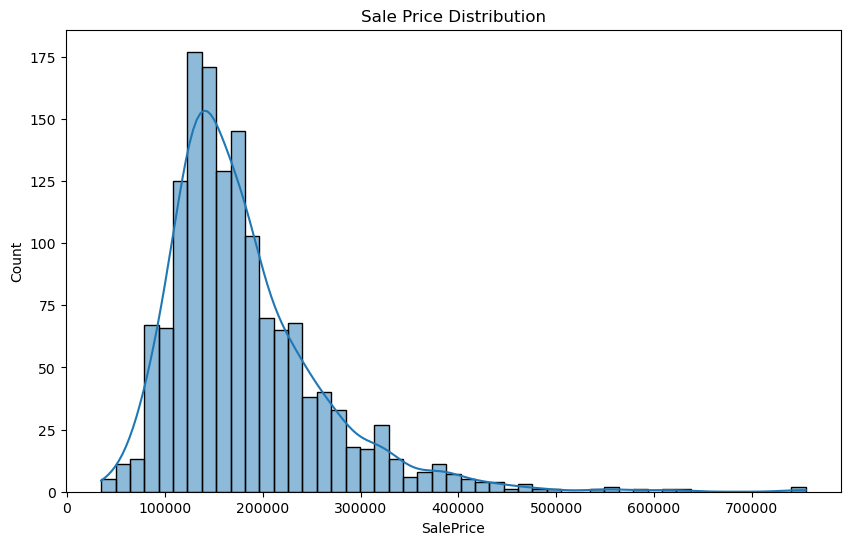

In [3]:
plt.figure(figsize=(10,6))
sns.histplot(df_train['SalePrice'], kde=True)
plt.title('Sale Price Distribution')
plt.show()

In [4]:
null_counts = df_train.isnull().sum().sort_values(ascending=False)
null_counts[null_counts > 0].head(10)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64

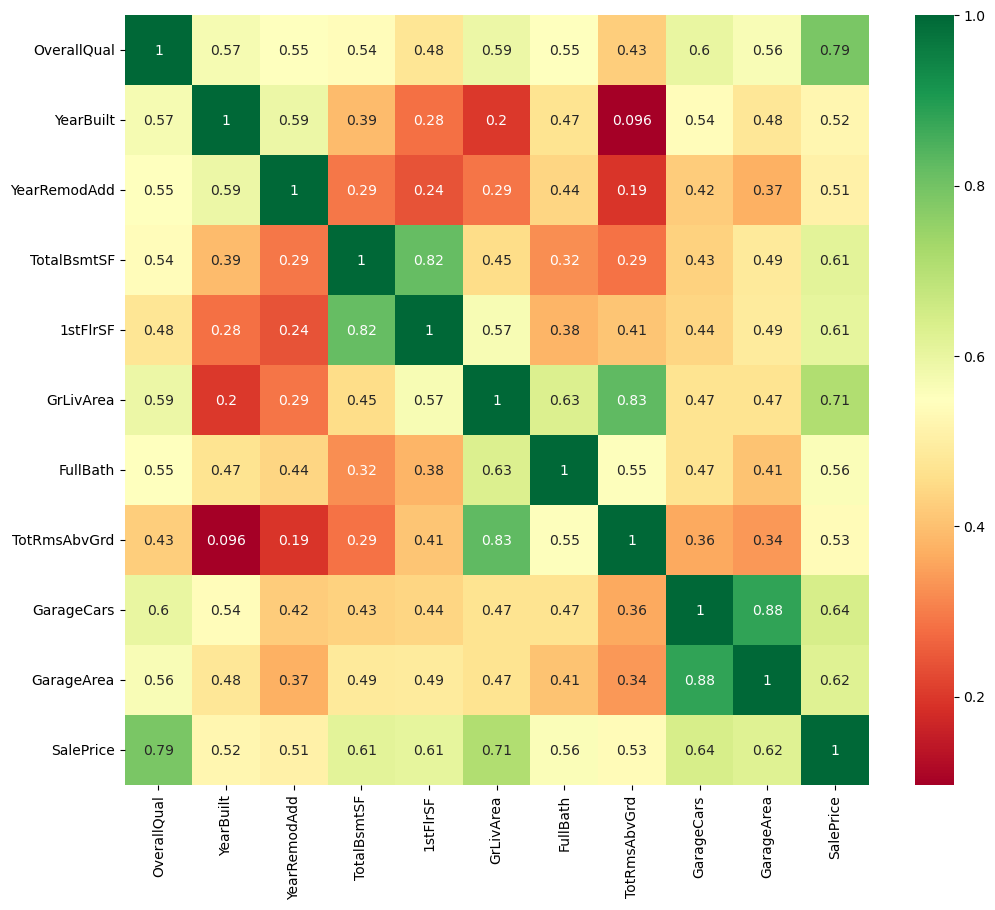

In [5]:
plt.figure(figsize=(12,10))
corrmat = df_train.corr(numeric_only=True)
top_corr_features = corrmat.index[abs(corrmat["SalePrice"])>0.5]
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap="RdYlGn")
plt.show()

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

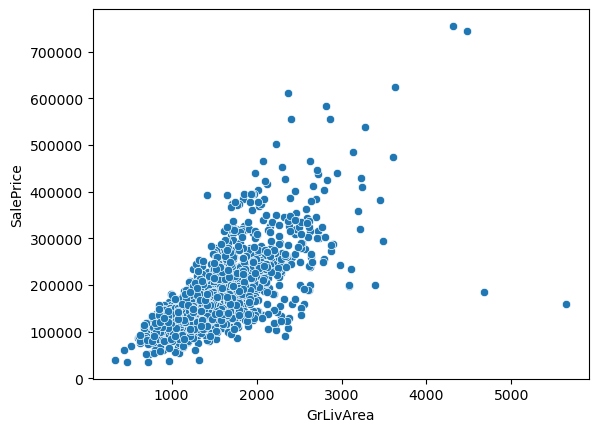

In [6]:
sns.scatterplot(data = df_train, x= 'GrLivArea', y= 'SalePrice')

In [7]:
df_train['PoolQC'].isna().sum()

1453

In [8]:
cols_to_fill_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                     'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                     'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                     'MasVnrType']

In [9]:
for col in cols_to_fill_none:
    df_train[col] = df_train[col].fillna('None')
    df_test[col] = df_test[col].fillna('None')

In [10]:
null_counts = df_train.isnull().sum().sort_values(ascending=False)
null_counts[null_counts > 0].head(10)

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Electrical       1
dtype: int64

In [11]:
df_train["LotFrontage"] = df_train.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))

In [12]:
df_train['HasGarage'] = df_train['GarageType'].apply(lambda x: 0 if x == 'None' else 1)
df_test['HasGarage'] = df_test['GarageType'].apply(lambda x: 0 if x == 'None' else 1)

df_train['GarageYrBlt'] = df_train['GarageYrBlt'].fillna(df_train['YearBuilt'])
df_test['GarageYrBlt'] = df_test['GarageYrBlt'].fillna(df_test['YearBuilt'])

df_train['GarageAge'] = df_train['YrSold'] - df_train['GarageYrBlt']
df_test['GarageAge'] = df_test['YrSold'] - df_test['GarageYrBlt']

df_train.drop('GarageYrBlt', axis=1, inplace=True)
df_test.drop('GarageYrBlt', axis=1, inplace=True)

In [13]:
df_train['MasVnrType'] = df_train['MasVnrType'].fillna('None')
df_train['MasVnrArea'] = df_train['MasVnrArea'].fillna(0)

df_test['MasVnrType'] = df_test['MasVnrType'].fillna('None')
df_test['MasVnrArea'] = df_test['MasVnrArea'].fillna(0)

In [14]:
null_counts = df_train.isnull().sum().sort_values(ascending=False)
null_counts[null_counts > 0].head(10)

Electrical    1
dtype: int64

In [15]:
df_train['Electrical'] = df_train['Electrical'].fillna(df_train['Electrical'].mode()[0])
df_test['Electrical'] = df_test['Electrical'].fillna(df_test['Electrical'].mode()[0])

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [17]:
categorical_cols = [col for col in df_train.columns if df_train[col].dtype=='object']
numerical_cols = [col for col in df_train.columns if df_train[col].dtype!='object']

In [18]:
def show_value_counts(df, cols):
    for col in cols:
        print(f"\n{col}")
        print('------------------')
        print(df[col].value_counts()
             )

In [19]:
show_value_counts(df_train,categorical_cols)


MSZoning
------------------
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street
------------------
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Alley
------------------
Alley
None    1369
Grvl      50
Pave      41
Name: count, dtype: int64

LotShape
------------------
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour
------------------
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities
------------------
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LotConfig
------------------
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

LandSlope
------------------
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Neighborhood
------------------
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    1

In [20]:
qual_mapping = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    df_train[col] = df_train[col].map(qual_mapping)
    df_test[col] = df_test[col].map(qual_mapping)

In [21]:
df_train['MSSubClass'] = df_train['MSSubClass'].astype(str)
df_train['OverallCond'] = df_train['OverallCond'].astype(str)
df_train['YrSold'] = df_train['YrSold'].astype(str)
df_train['MoSold'] = df_train['MoSold'].astype(str)


df_test['MSSubClass'] = df_test['MSSubClass'].astype(str)
df_test['OverallCond'] = df_test['OverallCond'].astype(str)
df_test['YrSold'] = df_test['YrSold'].astype(str)
df_test['MoSold'] = df_test['MoSold'].astype(str)

In [22]:
df_train['SalePrice'] = np.log1p(df_train['SalePrice'])

In [23]:
test_nulls = df_test.isnull().sum()
test_nulls[test_nulls > 0].sort_values(ascending=False)

LotFrontage     227
MSZoning          4
Utilities         2
BsmtFullBath      2
BsmtHalfBath      2
Functional        2
Exterior1st       1
Exterior2nd       1
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
KitchenQual       1
GarageCars        1
GarageArea        1
SaleType          1
dtype: int64

In [24]:
df_test["LotFrontage"] = df_test.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))

cols_to_zero = ['BsmtFullBath', 'BsmtHalfBath', 'BsmtFinSF1', 'BsmtFinSF2', 
                'BsmtUnfSF', 'TotalBsmtSF', 'GarageCars', 'GarageArea']

for col in cols_to_zero:
    df_test[col] = df_test[col].fillna(0)

df_test['KitchenQual'] = df_test['KitchenQual'].fillna(df_test['KitchenQual'].mode()[0])

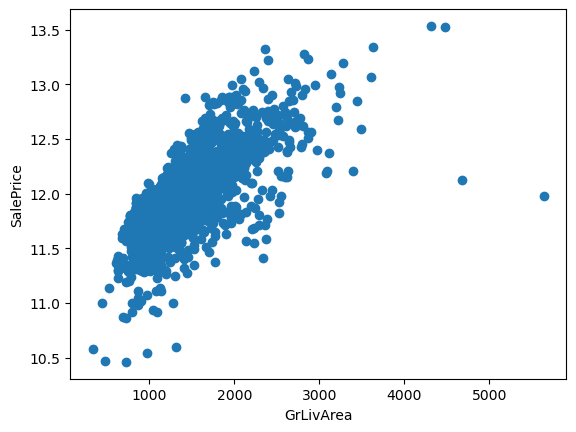

In [25]:
plt.scatter(x=df_train['GrLivArea'], y=df_train['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('GrLivArea')
plt.show()

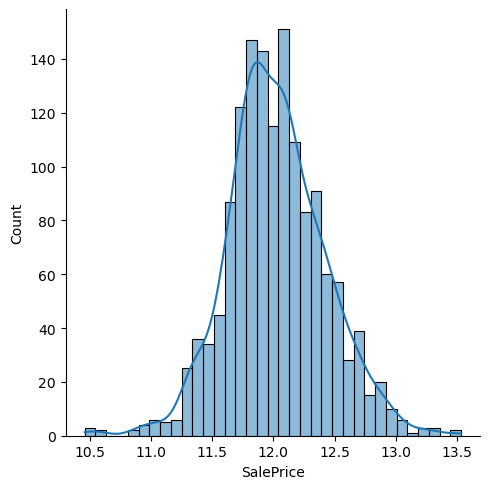

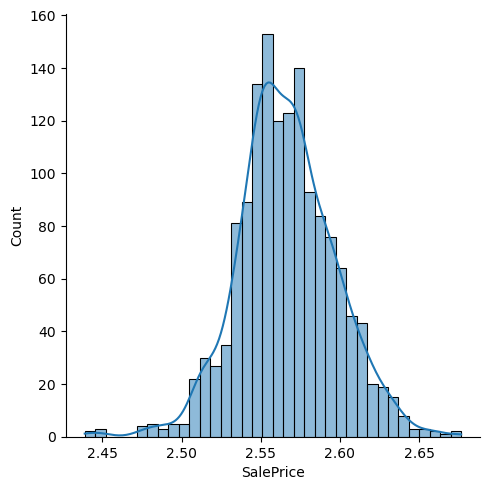

In [26]:
sns.displot(df_train['SalePrice'], kde=True)
y = np.log1p(df_train['SalePrice'])
sns.displot(y, kde=True)

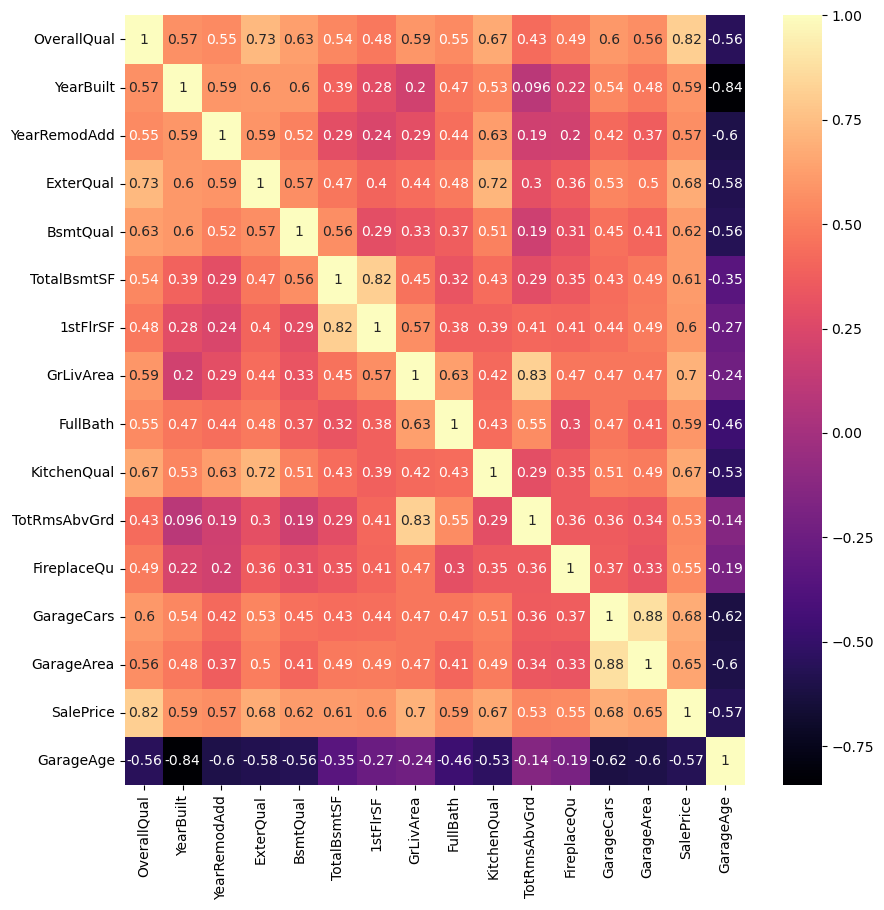

In [27]:
corrmat = df_train.corr(numeric_only=True)
top_corr_features = corrmat.index[abs(corrmat["SalePrice"])>0.5]
plt.figure(figsize=(10,10))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap="magma")
plt.show()

In [28]:
y_train = df_train['SalePrice'] 

train_ID = df_train['Id']
test_ID = df_test['Id']

df_train_features = df_train.drop(['Id', 'SalePrice'], axis=1)
df_test_features = df_test.drop(['Id'], axis=1)

ntrain = df_train_features.shape[0]
all_data = pd.concat((df_train_features, df_test_features)).reset_index(drop=True)

all_data = pd.get_dummies(all_data, dtype=int)

X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

In [29]:
y = y_train

X = X_train 

X_kaggle_test = X_test

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor

from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet,BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [32]:
models = {
     'linear Regressin' : LinearRegression(),
     'Ridge': Ridge(),
     'Lasso': Lasso(),
     'ElasticNet': ElasticNet(),
     'BayesianRidge': BayesianRidge(),
     'SVR': SVR(),
     'Kneighbours Reg': KNeighborsRegressor(),
     'Decision Tree': DecisionTreeRegressor(),
     'Random forest': RandomForestRegressor(),
     'Adaboost': AdaBoostRegressor(),
     'Gradient': GradientBoostingRegressor(),
     'Xgboost': XGBRegressor(),
     'LighGBM': LGBMRegressor(),
     'CatBoost': CatBoostRegressor(verbose=False)
}

In [33]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [34]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae,train_rmse,train_r2 = calculate_model_metrics(y_train,y_train_pred)
    test_mae,test_rmse,test_r2 = calculate_model_metrics(y_test,y_test_pred)

    print(list(models.keys())[i])
    print('model performance for Training Set')
    print('Root mean absolute error: ',train_mae)
    print('Root rmse: ',train_rmse)
    print('Root r2 score: ',train_r2)
    print('-------------------------------')
    print('model performance for Test Set')
    print('test mean absolute error: ',test_mae)
    print(' test rmse: ',test_rmse)
    print('test r2 score: ',test_r2)
    print('******************************')
    print('******************************')

linear Regressin
model performance for Training Set
Root mean absolute error:  0.06289976145191398
Root rmse:  0.09120664162611034
Root r2 score:  0.9454308673944616
-------------------------------
model performance for Test Set
test mean absolute error:  0.08830829994744721
 test rmse:  0.12738646948986002
test r2 score:  0.9130420307411369
******************************
******************************
Ridge
model performance for Training Set
Root mean absolute error:  0.06861795454013803
Root rmse:  0.09818728123320937
Root r2 score:  0.936758146343752
-------------------------------
model performance for Test Set
test mean absolute error:  0.09075800971657122
 test rmse:  0.12692801717331287
test r2 score:  0.9136668120920304
******************************
******************************
Lasso
model performance for Training Set
Root mean absolute error:  0.12389800063483253
Root rmse:  0.19368676918443742
Root r2 score:  0.7539099632090316
-------------------------------
model perform

In [35]:
X_train.head()

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,70.0,8400,5,1957,1957,0.0,3,4,3,3,...,0,0,0,1,0,0,0,0,1,0
1066,59.0,7837,6,1993,1994,0.0,4,3,4,3,...,0,0,0,1,0,0,0,0,1,0
638,67.0,8777,5,1910,1950,0.0,3,3,2,3,...,0,0,0,1,0,0,0,0,1,0
799,60.0,7200,5,1937,1950,252.0,3,3,4,3,...,0,0,0,1,0,0,0,0,1,0
380,50.0,5000,5,1924,1950,0.0,3,3,3,3,...,0,0,0,1,0,0,0,0,1,0


In [36]:
from sklearn.preprocessing import TargetEncoder

In [37]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   object 
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [38]:
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


X = df_train.drop(columns=['Id', 'SalePrice'])
y = df_train['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Числовые признаки: {numeric_features}")
print(f"Категориальные признаки: {categorical_features}")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', TargetEncoder(target_type='continuous'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor.fit(X_train, y_train)

X_train_encoded = preprocessor.transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(f"\nРазмеры после трансформации:")
print(f"X_train: {X_train_encoded.shape}")
print(f"X_test: {X_test_encoded.shape}")

Числовые признаки: ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'MiscVal', 'HasGarage', 'GarageAge']
Категориальные признаки: ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electric

In [39]:
feature_names = preprocessor.get_feature_names_out()

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=feature_names,
    index=X_test.index
)

In [40]:
X_train_encoded.dtypes

num__LotFrontage      float64
num__LotArea          float64
num__OverallQual      float64
num__YearBuilt        float64
num__YearRemodAdd     float64
                       ...   
cat__MiscFeature      float64
cat__MoSold           float64
cat__YrSold           float64
cat__SaleType         float64
cat__SaleCondition    float64
Length: 80, dtype: object

In [41]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_encoded,y_train)
    y_train_pred = model.predict(X_train_encoded)
    y_test_pred = model.predict(X_test_encoded)

    train_mae,train_rmse,train_r2 = calculate_model_metrics(y_train,y_train_pred)
    test_mae,test_rmse,test_r2 = calculate_model_metrics(y_test,y_test_pred)

    print(list(models.keys())[i])
    print('model performance for Training Set')
    print('Root mean absolute error: ',train_mae)
    print('Root rmse: ',train_rmse)
    print('Root r2 score: ',train_r2)
    print('-------------------------------')
    print('model performance for Test Set')
    print('test mean absolute error: ',test_mae)
    print(' test rmse: ',test_rmse)
    print('test r2 score: ',test_r2)
    print('******************************')
    print('******************************')

linear Regressin
model performance for Training Set
Root mean absolute error:  0.08705105289855106
Root rmse:  0.12655086577661565
Root r2 score:  0.8949431529493937
-------------------------------
model performance for Test Set
test mean absolute error:  0.09955391036428055
 test rmse:  0.14113322414513027
test r2 score:  0.8932614466693287
******************************
******************************
Ridge
model performance for Training Set
Root mean absolute error:  0.08740445906405249
Root rmse:  0.12736430019089445
Root r2 score:  0.8935882589945207
-------------------------------
model performance for Test Set
test mean absolute error:  0.0989550826956227
 test rmse:  0.1404009492958073
test r2 score:  0.8943662068766163
******************************
******************************
Lasso
model performance for Training Set
Root mean absolute error:  0.3033671860808526
Root rmse:  0.390438773030285
Root r2 score:  0.0
-------------------------------
model performance for Test Set
t

In [42]:
from sklearn.model_selection import RandomizedSearchCV

In [91]:
param_dist_simple = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    'max_depth': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, None],
    'max_samples': [0.6, 0.7, 0.8, 0.9, None]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=param_dist_simple,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

In [93]:
random_search.fit(X_train_encoded, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'max_samples': [0.6, 0.7, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can 

In [94]:
random_search.best_params_

{'n_estimators': 600,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_samples': None,
 'max_features': 0.3,
 'max_depth': 35}

In [103]:
from sklearn.model_selection import cross_validate

model = RandomForestRegressor(n_estimators=600, min_samples_split=2, min_samples_leaf=2, max_samples=None, max_features=0.3, max_depth=35)
scores = cross_validate(model, X_train_encoded, y_train, cv=3,
                        scoring=('neg_mean_absolute_error', 'neg_mean_squared_error'),
                        return_train_score=True)

In [121]:
score = np.mean(np.sqrt(np.abs(scores['test_neg_mean_squared_error'])))

In [123]:
score

0.1356923186545478